<a href="https://colab.research.google.com/github/MOHAMMAD-Ghouse/Machine-Learning-on-Big-Data-Portfolio/blob/main/Week_8_AAPL_Stock_Price_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install pyspark -q

import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

spark = (
    SparkSession.builder
    .appName("AAPLStockForecasting")
    .getOrCreate()
)

print("Spark Version:", spark.version)

Spark Version: 4.0.4


In [2]:
DATA_PATH = "/content/aapl_stock_data.csv"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(DATA_PATH)
)

df = df.withColumn("Date", F.to_date("Date"))

print("Total Rows:", df.count())
print("Total Columns:", len(df.columns))

df.printSchema()
df.show(5)

Total Rows: 6213
Total Columns: 9
root
 |-- Date: date (nullable = true)
 |-- Open: double (nullable = true)
 |-- High: double (nullable = true)
 |-- Low: double (nullable = true)
 |-- Close: double (nullable = true)
 |-- Volume: integer (nullable = true)
 |-- PERatio: double (nullable = true)
 |-- EPS: double (nullable = true)
 |-- MarketCap: long (nullable = true)

+----------+-----+-----+-----+-----+-------+-------+----+-------------+
|      Date| Open| High|  Low|Close| Volume|PERatio| EPS|    MarketCap|
+----------+-----+-----+-----+-----+-------+-------+----+-------------+
|1999-11-01| 80.0|80.69|77.37|77.62|2487300|  35.85|6.43|3535123251000|
|1999-11-02| 78.0|81.69|77.31|80.25|3564600|  35.85|6.43|3535123251000|
|1999-11-03|81.62|83.25| 81.0| 81.5|2932700|  35.85|6.43|3535123251000|
|1999-11-04|82.06|85.37|80.62|83.62|3384700|  35.85|6.43|3535123251000|
|1999-11-05|84.62|88.37| 84.0|88.31|3721500|  35.85|6.43|3535123251000|
+----------+-----+-----+-----+-----+-------+-------+--

In [3]:
df = df.dropna()

print("Missing values checked and removed.")

print("Date Range:")
df.select(
    F.min("Date").alias("Start_Date"),
    F.max("Date").alias("End_Date")
).show()

print("Price Summary:")
df.select(
    "Open", "High", "Low", "Close"
).describe().show()

# Create next-day closing price as target
window_spec = Window.orderBy("Date")

df_features = (
    df
    .withColumn("previous_close", F.lag("Close", 1).over(window_spec))
    .withColumn("target_close", F.lead("Close", 1).over(window_spec))
    .dropna()
)

df_features.select(
    "Date",
    "Close",
    "previous_close",
    "target_close"
).show(5)

Missing values checked and removed.
Date Range:
+----------+----------+
|Start_Date|  End_Date|
+----------+----------+
|1999-11-01|2024-07-12|
+----------+----------+

Price Summary:
+-------+------------------+------------------+------------------+------------------+
|summary|              Open|              High|               Low|             Close|
+-------+------------------+------------------+------------------+------------------+
|  count|              6213|              6213|              6213|              6213|
|   mean|173.66832021567694|175.59368546595732|171.64628921616014|173.67797978432267|
| stddev| 147.8527704461231|149.07249323322557|146.43412941826261|147.78918659431955|
|    min|             12.99|             13.19|             12.72|             13.12|
|    max|            702.41|            705.07|            699.57|             702.1|
+-------+------------------+------------------+------------------+------------------+

+----------+-----+--------------+--------

In [4]:
feature_columns = [
    "Open",
    "High",
    "Low",
    "Close",
    "Volume",
    "previous_close"
]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features"
)

data = assembler.transform(df_features)

# Chronological split to prevent time-series leakage
split_date = (
    data
    .select(
        F.expr("percentile_approx(unix_timestamp(Date), 0.8)")
        .alias("split_point")
    )
    .collect()[0]["split_point"]
)

train_data = data.filter(
    F.unix_timestamp("Date") <= split_date
)

test_data = data.filter(
    F.unix_timestamp("Date") > split_date
)

print("Training Records:", train_data.count())
print("Testing Records:", test_data.count())

data.select(
    "Date",
    "features",
    "target_close"
).show(5, truncate=False)

Training Records: 4968
Testing Records: 1243
+----------+-----------------------------------------+------------+
|Date      |features                                 |target_close|
+----------+-----------------------------------------+------------+
|1999-11-02|[78.0,81.69,77.31,80.25,3564600.0,77.62] |81.5        |
|1999-11-03|[81.62,83.25,81.0,81.5,2932700.0,80.25]  |83.62       |
|1999-11-04|[82.06,85.37,80.62,83.62,3384700.0,81.5] |88.31       |
|1999-11-05|[84.62,88.37,84.0,88.31,3721500.0,83.62] |96.37       |
|1999-11-08|[87.75,97.73,86.75,96.37,8490400.0,88.31]|89.62       |
+----------+-----------------------------------------+------------+
only showing top 5 rows


In [5]:
# Linear Regression
lr = LinearRegression(
    featuresCol="features",
    labelCol="target_close"
)

lr_model = lr.fit(train_data)

lr_predictions = lr_model.transform(test_data)


# Gradient Boosted Tree
gbt = GBTRegressor(
    featuresCol="features",
    labelCol="target_close",
    maxIter=30,
    maxDepth=5,
    seed=42
)

gbt_model = gbt.fit(train_data)

gbt_predictions = gbt_model.transform(test_data)


# Evaluation
metrics = ["mae", "rmse", "r2"]

results = []

for metric in metrics:

    evaluator = RegressionEvaluator(
        labelCol="target_close",
        predictionCol="prediction",
        metricName=metric
    )

    lr_score = evaluator.evaluate(lr_predictions)
    gbt_score = evaluator.evaluate(gbt_predictions)

    results.append(
        (metric.upper(), float(lr_score), float(gbt_score))
    )

results_df = spark.createDataFrame(
    results,
    ["Metric", "Linear Regression", "GBT Regressor"]
)

results_df.show()

+------+------------------+------------------+
|Metric| Linear Regression|     GBT Regressor|
+------+------------------+------------------+
|   MAE| 3.009969374554622| 5.969737123571527|
|  RMSE|11.341692828527247|14.008450141747188|
|    R2|0.9734552203012736|0.9595048006762186|
+------+------------------+------------------+



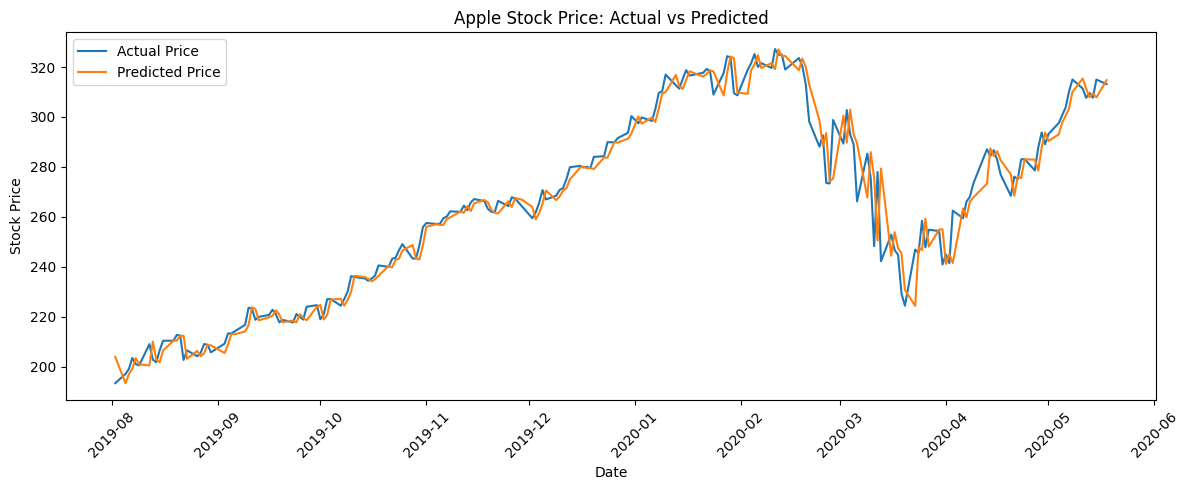


APPLE STOCK PRICE FORECASTING USING PYSPARK

PROJECT COMPLETED SUCCESSFULLY

DATA PROCESSING:
• Spark DataFrames
• Time-series ordering
• Lag feature creation
• Next-day price prediction
• Chronological train/test split

MACHINE LEARNING MODELS:
• Linear Regression
• Gradient Boosted Tree Regressor

MODEL EVALUATION:
• MAE
• RMSE
• R² Score

CONCLUSION:
Historical Apple stock data was processed using
PySpark to forecast the next trading day's closing
price. Lag features were created using Spark Window
functions, and a chronological split was used to
avoid future data leakage.

Linear Regression and Gradient Boosted Tree models
were trained and compared using regression metrics.

PROJECT COMPLETE



In [6]:
plot_data = (
    lr_predictions
    .select("Date", "target_close", "prediction")
    .orderBy("Date")
    .limit(200)
    .toPandas()
)

plt.figure(figsize=(12, 5))

plt.plot(
    plot_data["Date"],
    plot_data["target_close"],
    label="Actual Price"
)

plt.plot(
    plot_data["Date"],
    plot_data["prediction"],
    label="Predicted Price"
)

plt.title("Apple Stock Price: Actual vs Predicted")
plt.xlabel("Date")
plt.ylabel("Stock Price")
plt.legend()

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


print("""
====================================================
APPLE STOCK PRICE FORECASTING USING PYSPARK
====================================================

PROJECT COMPLETED SUCCESSFULLY

DATA PROCESSING:
• Spark DataFrames
• Time-series ordering
• Lag feature creation
• Next-day price prediction
• Chronological train/test split

MACHINE LEARNING MODELS:
• Linear Regression
• Gradient Boosted Tree Regressor

MODEL EVALUATION:
• MAE
• RMSE
• R² Score

CONCLUSION:
Historical Apple stock data was processed using
PySpark to forecast the next trading day's closing
price. Lag features were created using Spark Window
functions, and a chronological split was used to
avoid future data leakage.

Linear Regression and Gradient Boosted Tree models
were trained and compared using regression metrics.

====================================================
PROJECT COMPLETE
====================================================
""")